## 1. Import Required Libraries

In [1]:
!pip install tensorflow scikit-learn opencv-python matplotlib seaborn


import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD, Adam


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 422.2 kB/s eta 0:01:35
   


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\Sabarithan P\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## 2. Load Dataset

In [6]:
DATASET_PATH = "Img"
IMG_SIZE = 28

X = []
y = []

for img_name in os.listdir(DATASET_PATH):
    img_path = os.path.join(DATASET_PATH, img_name)

    # skip if not an image
    if not img_name.lower().endswith((".png", ".jpg", ".jpeg")):
        continue

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    X.append(img)

    # 🔑 label from filename (example: img001-001.png → 001)
    label = img_name.split("-")[0]   # adjust if needed
    y.append(label)

X = np.array(X)
y = np.array(y)

print("Samples:", X.shape[0])
print("Image shape:", X.shape[1:])
print("Labels example:", y[:5])

Samples: 3410
Image shape: (28, 28)
Labels example: ['img001' 'img001' 'img001' 'img001' 'img001']


## 3. Preoprocessing of Data

In [8]:
# Flatten + Normalize
X = X.reshape(X.shape[0], -1) / 255.0

le = LabelEncoder()
y_encoded = le.fit_transform(y)

num_classes = len(np.unique(y_encoded))
print("Classes:", num_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


Classes: 62


## 4. PLA-single layer perceptron learning algorithm

In [10]:
class PerceptronOVR:
    def __init__(self, lr=0.01, epochs=20):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.W = np.zeros((len(self.classes), X.shape[1]))

        for idx, c in enumerate(self.classes):
            y_binary = np.where(y == c, 1, -1)
            w = np.zeros(X.shape[1])

            for _ in range(self.epochs):
                for i in range(X.shape[0]):
                    if y_binary[i] * np.dot(X[i], w) <= 0:
                        w += self.lr * y_binary[i] * X[i]

            self.W[idx] = w

    def predict(self, X):
        scores = np.dot(X, self.W.T)
        return np.argmax(scores, axis=1)


## 5. Train pla

In [11]:
pla = PerceptronOVR(lr=0.01, epochs=10)
pla.fit(X_train, y_train)

y_pred_pla = pla.predict(X_test)

pla_acc = accuracy_score(y_test, y_pred_pla)
pla_prec, pla_rec, pla_f1, _ = precision_recall_fscore_support(y_test, y_pred_pla, average='macro')

print("PLA Accuracy:", pla_acc)


PLA Accuracy: 0.09090909090909091


C:\Users\Sabarithan P\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 6. MLP model building

In [12]:
def build_mlp(hidden_layers, activation, optimizer, lr):
    model = Sequential()

    model.add(Dense(hidden_layers[0], activation=activation, input_shape=(X.shape[1],)))

    for units in hidden_layers[1:]:
        model.add(Dense(units, activation=activation))

    model.add(Dense(num_classes, activation='softmax'))

    if optimizer == "adam":
        opt = Adam(learning_rate=lr)
    else:
        opt = SGD(learning_rate=lr)

    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=opt,
                  metrics=['accuracy'])

    return model


## 7. Hyperparameter tuning

In [13]:
configs = [
    ([128], "relu", "sgd", 0.01, 32),
    ([256,128], "relu", "adam", 0.001, 64),
    ([512,256,128], "tanh", "adam", 0.0005, 64)
]

results = []

for layers, act, opt, lr, batch in configs:
    model = build_mlp(layers, act, opt, lr)
    history = model.fit(X_train, y_train, epochs=15, batch_size=batch, verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    results.append([layers, act, opt, lr, batch, acc*100])


C:\Users\Sabarithan P\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 8. Hyperparameter Results

In [14]:
print("\nTable 2: Hyperparameter Tuning Results")
for r in results:
    print(r)



Table 2: Hyperparameter Tuning Results
[[128], 'relu', 'sgd', 0.01, 32, 1.7595307901501656]
[[256, 128], 'relu', 'adam', 0.001, 64, 4.105572029948235]
[[512, 256, 128], 'tanh', 'adam', 0.0005, 64, 16.275659203529358]


## 9. Final tuned mlp

In [15]:
final_model = build_mlp([512,256,128], "relu", "adam", 0.001)

history = final_model.fit(
    X_train, y_train,
    epochs=240,
    batch_size=128,
    validation_split=0.1,
    shuffle=True
)


Epoch 1/240
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.0155 - loss: 4.1283 - val_accuracy: 0.0073 - val_loss: 4.1289
Epoch 2/240
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0155 - loss: 4.1274 - val_accuracy: 0.0073 - val_loss: 4.1293
Epoch 3/240
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0118 - loss: 4.1272 - val_accuracy: 0.0073 - val_loss: 4.1315
Epoch 4/240
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0159 - loss: 4.1270 - val_accuracy: 0.0073 - val_loss: 4.1326
Epoch 5/240
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0167 - loss: 4.1268 - val_accuracy: 0.0110 - val_loss: 4.1339
Epoch 6/240
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0138 - loss: 4.1267 - val_accuracy: 0.0073 - val_loss: 4.1341
Epoch 7/240
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0171 - loss: 4.1265 - val_accuracy: 0.0110 - val_loss: 4.1376
Epoch 8/240
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0179 - loss: 4.1261 - val_accuracy: 0.0073 - 

## 10. MLP Evaluation

In [16]:
y_pred_mlp = np.argmax(final_model.predict(X_test), axis=1)

mlp_acc = accuracy_score(y_test, y_pred_mlp)
mlp_prec, mlp_rec, mlp_f1, _ = precision_recall_fscore_support(y_test, y_pred_mlp, average='macro')

print("MLP Accuracy:", mlp_acc)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MLP Accuracy: 0.16862170087976538


C:\Users\Sabarithan P\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 11. Performance comparison

In [17]:
print("\nTable 1: Overall Performance\n")
print("Model\tAccuracy\tPrecision\tRecall\tF1")
print("PLA\t", round(pla_acc,3), round(pla_prec,3), round(pla_rec,3), round(pla_f1,3))
print("MLP\t", round(mlp_acc,3), round(mlp_prec,3), round(mlp_rec,3), round(mlp_f1,3))



Table 1: Overall Performance

Model	Accuracy	Precision	Recall	F1
PLA	 0.091 0.121 0.091 0.055
MLP	 0.169 0.135 0.169 0.137


## 12. Confusion matrix

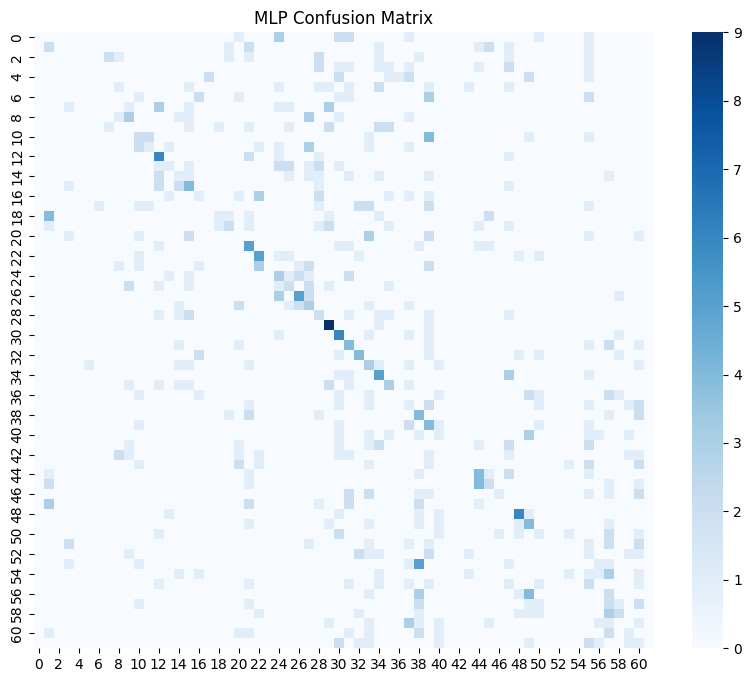

In [18]:
cm = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("MLP Confusion Matrix")
plt.show()


## 13. ROC -curve

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


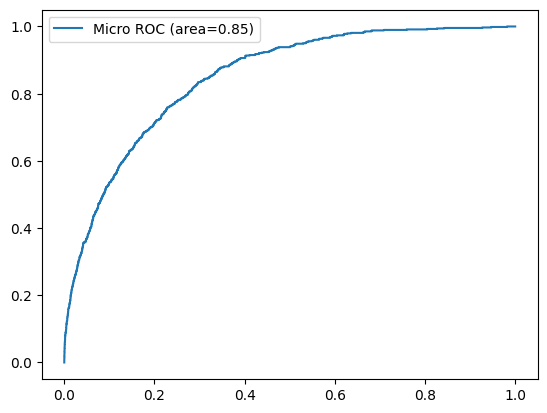

In [19]:
y_test_bin = label_binarize(y_test, classes=range(num_classes))
y_score = final_model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="Micro ROC (area=%0.2f)" % roc_auc)
plt.legend()
plt.show()


## 14. Loss curve

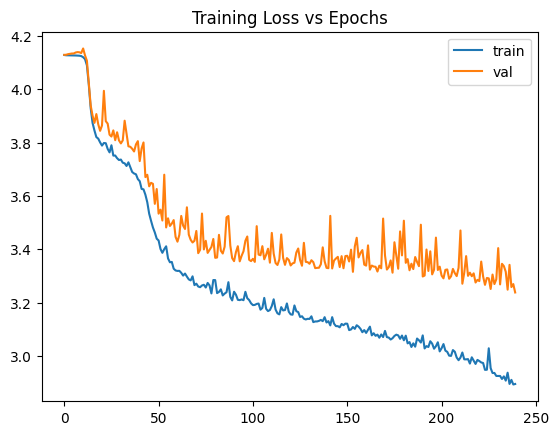

In [20]:
plt.plot(history.history['loss'], label="train")
plt.plot(history.history['val_loss'], label="val")
plt.legend()
plt.title("Training Loss vs Epochs")
plt.show()
